<h1><center>easy-pygeoid Tutorials</center></h1>
<h2><center>Gravity Field Functionals from Global Models</center></h2>

This notebook demonstrates how to use the open-source [easy-pygeoid](https://github.com/cikelly/easy-pygeoid) package for gravity field modeling. `easy-pygeoid` is a highly-automated Python package with several optimization techniques to facilitate fast and easy geoid modeling. The modules in the package are highly modular and can be extended beyond geoid modeling to height system unification -- this extension requires technical expertise in both Python and gravity field modeling.

Some key functionalities in `easy-pygeoid` are:
- Automatic download of data -- global geopotential models, elevation data
- Numba optimized functions to speed up computations
- Vectorized numpy operations for gridded data to speed up computations 
- Option to divide and process large datasets in chunks
- Terrain correction
- Residual Terrain Modeling (RTM)

`easy-pygeoid` can be used for geoid and height system research (and publications), and can also be used to give students practical lessons on gravity modeling.

If you use `easy-pygeoid` in your research, please acknowledge it by citing the relevant source:
- Yakubu, C. I., Ferreira, V. G. and Asante, C. Y., (2017): [Towards the Selection of an Optimal Global Geopotential
Model for the Computation of the Long-Wavelength Contribution: A Case Study of Ghana, Geosciences, 7(4), 113](http://www.mdpi.com/2076-3263/7/4/113)

- C. I. Kelly, S. A. Andam-Akorful, C. M. Hancock, P. B. Laari & J. Ayer (2021): [Global gravity models and the Ghanaian vertical datum: challenges of a proper definition, Survey Review, 53(376), 44–54](https://doi.org/10.1080/00396265.2019.1684006)

Let's start by running the IPython magic commands `%load_ext autoreload` and `%autoreload 2`. These are essential for when we make changes to our functions after we have already imported modules from a script. This allows the changes to take effect so that we do not need to restart the kernel.

For this tutorial, this step is not absolutely necessary. However, if you create your own functions in scripts that you use in this Notebook, you may find this helpful.

- `%load_ext autoreload`: This magic command loads the autoreload extension. The autoreload extension is designed to reload modules before executing your code, which can be very useful during the development of a large project.
- `%autoreload 2`: This magic command sets the autoreload mode. The argument 2 means that all modules (except those excluded by %aimport) are reloaded every time before executing the Python code typed. This is very useful when you’re working on a module and want to test changes in a Jupyter notebook without having to restart the kernel.

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
# import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd

plt.rcParams.update({'font.family': 'Arial', 'font.size':10})

# sys.path.append('../src')
from geoidlab import shtools
from geoidlab import icgem
from geoidlab import ggm as ggm_tools

home_dir = os.getcwd()
data_dir = os.path.join(home_dir, 'data')

# Download and read spherical harmonic coefficients (ICGEM format)

The function `read_shc` in `../utils/shtools` can be used to read certain attributes from a `.gfc` file downloaded from [ICGEM](https://icgem.gfz-potsdam.de/tom_longtime). 

In [5]:
model = 'GO_CONS_GCF_2_TIM_R6e'
icgem.download_ggm(model_name=model)

fname = 'downloads/' + model + '.gfc'

shc = icgem.read_icgem(fname)
print(f'\nData type of shc: {type(shc)}')

GO_CONS_GCF_2_TIM_R6e.gfc: 100%|██████████| 5.32M/5.32M [00:01<00:00, 2.87MiB/s]



GO_CONS_GCF_2_TIM_R6e.gfc saved to /Users/kelly/Documents/Github/geoidlab/Notebooks/downloads

Data type of shc: <class 'dict'>


`read_shc` returns a dict, which contains:

<pre>
- 'a'       : The reference radius.
- 'nmax'    : The maximum degree of expansion.
- 'GM'      : The Earth's gravitational constant.
- 'Cnm'     : A numpy array containing the cosine coefficients.
- 'Snm'     : A numpy array containing the sine coefficients.
- 'sCnm'    : A numpy array containing the formal cosine errors.
- 'sSnm'    : A numpy array containing the formal sine errors.
- 'tide_sys': The tide system used in the model.
</pre>

We can print out radius, nmax, GM, and tide system and compare with the values in `model` (open the .gfc file in a text editor to see these values). For reference, the values in the `.gfc` file are:

<pre>
- radius                 (a)          : 6378136.46
- max_degree             (nmax)       : 300
- earth_gravity_constant (GM)         : 3.986004415E+14
- tide_system            (tide_sys)   : zero_tide
</pre>


In [6]:
for key in ['a', 'nmax', 'GM', 'tide_sys']:
    print(f'{key:<10}: {shc[key]}')

a         : 6378136.46
nmax      : 300
GM        : 398600441500000.0
tide_sys  : zero_tide


An important part of the computation is the subtraction of the reference ellipsoid, defined by the semi-major axis of the Earth $a$ and the flattening parameter $f$. To do so, the zonal coefficients of the spherical harmonic gravity model $\bar{C}_{2n,0}$, $n=1,2,3,4,5$ are corrected by
\begin{equation}
\bar{C}_{2n,0} = \bar{C}_{2n,0} + \frac{GM}{GM_g}\left(\frac{a}{a_g}\right)^n\cdot\frac{J_n}{\sqrt{4n+1}}.
\end{equation}

The factor $(GM/GM_g)\cdot(a/a_g)^n$ accounts for the fact that neither the gravity mass constant nor the semi-major axes (just a scaling factor for the geopotential model) have to be the same for geopotential model and reference ellipsoid. In fact, very often they are not the same. In general, it is sufficient to correct the zonal coefficients $\bar{C}_{2,0}$ through $\bar{C}_{10,0}$. The coefficients $J_{2n}$ are determined from the parameters $a, f, $ and the angular velocity $\omega$ of the Earth by an expansion
\begin{equation}
J_{2n} = (-1)^{n+1}\frac{3e^{2n}}{(2n+1)(2n+3)}\left(1-n+5n\frac{C-A}{ME^2}\right),
\end{equation}

\begin{equation}
\frac{C-A}{ME^2} = \frac{1}{3}\left[1-\frac{2}{15}\left(\frac{me'}{q_0}\right)\right]
\end{equation}

\begin{equation}
m = \frac{\omega^2a^2b}{GM}
\end{equation}

\begin{equation}
q_0 = \frac{1}{2}\left[\left(1+\frac{3}{e'^2}\arctan e' - \frac{3}{e'}\right)\right]
\end{equation}

\begin{equation}
e' = \frac{E}{b}
\end{equation}

In [10]:
-4.841698763178854E-04, -0.0004841698763178854

(-0.0004841698763178854, -0.0004841698763178854)

In [13]:
-2.868373013718492e-09

-2.868373013718492e-09

In [8]:
Cnm = shc['Cnm']
Cnm

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-4.84169876e-04, -2.67940338e-10,  2.43939030e-06, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-9.14600243e-11,  9.12745642e-11, -5.02173898e-11, ...,
        -3.86196538e-11,  0.00000000e+00,  0.00000000e+00],
       [ 2.26259310e-11, -6.58343235e-11,  1.07917396e-11, ...,
        -3.48949238e-11, -3.43712772e-12,  0.00000000e+00],
       [ 3.75081469e-11,  1.51340067e-10,  1.11034044e-11, ...,
         2.97130584e-12, -3.46781416e-11, -1.06179843e-11]])

In [12]:
import copy
shc_copy = copy.deepcopy(shc)

shc_copy = shtools.subtract_zonal_harmonics(shc_copy, ellipsoid='grs80')
Cnm_zonal = shc_copy['Cnm']
Cnm_zonal

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.86837301e-09, -2.67940338e-10,  2.43939030e-06, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-9.14600243e-11,  9.12745642e-11, -5.02173898e-11, ...,
        -3.86196538e-11,  0.00000000e+00,  0.00000000e+00],
       [ 2.26259310e-11, -6.58343235e-11,  1.07917396e-11, ...,
        -3.48949238e-11, -3.43712772e-12,  0.00000000e+00],
       [ 3.75081469e-11,  1.51340067e-10,  1.11034044e-11, ...,
         2.97130584e-12, -3.46781416e-11, -1.06179843e-11]])

# Degree Variances

Constants from the global geopotential model

In [ ]:
# variances1 = shtools.degree_amplitude1(shc, ellipsoid='grs80')
variances  = shtools.degree_amplitude(shc, ellipsoid='grs80', replace_zonal=False)
error_variances = shtools.error_degree_amplitude(shc, ellipsoid='grs80', replace_zonal=False)

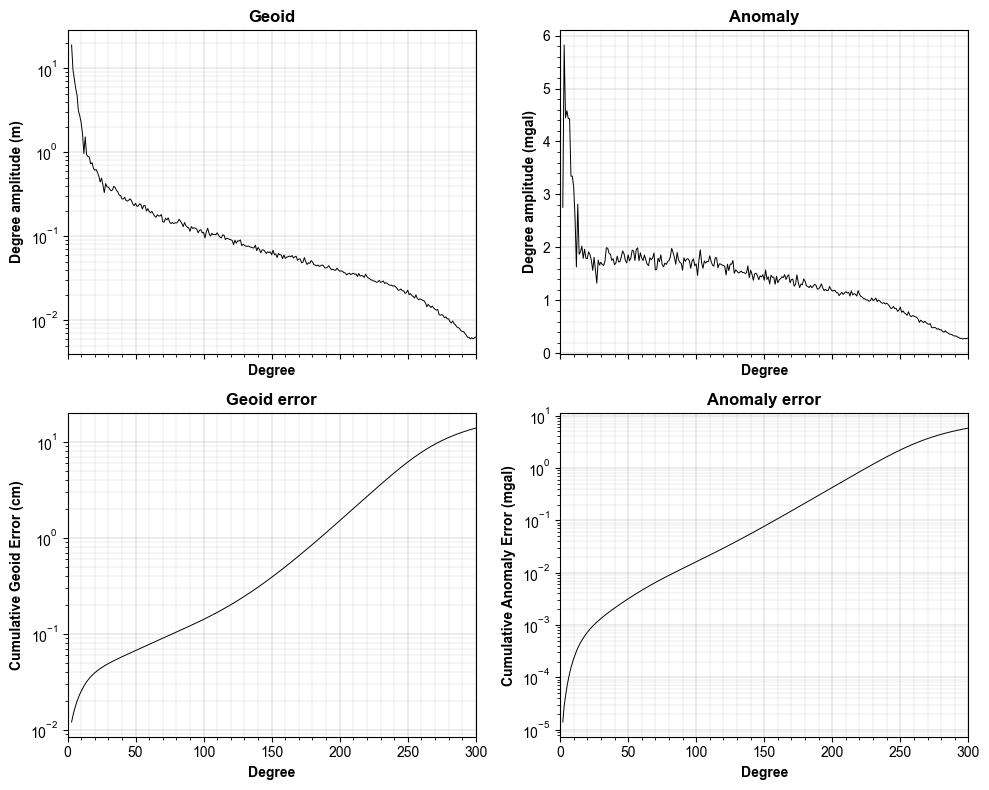

In [17]:
fig, axs = plt.subplots(2,2, figsize=(10,8), sharex=True)

axs = axs.ravel()

axs[0].plot(variances['degree'][3:], variances['geoid'][3:], linewidth=0.7, color='k')
axs[1].plot(variances['degree'][2:], variances['anomaly'][2:], linewidth=0.7, color='k')
axs[2].plot(error_variances['degree'][3:], error_variances['error_geoid'][3:], linewidth=0.7, color='k')
axs[3].plot(error_variances['degree'][2:], error_variances['error_anomaly'][2:], linewidth=0.7, color='k')

titles = ['Geoid', 'Anomaly', 'Geoid error', 'Anomaly error']
ylabels = ['Degree amplitude (m)', 'Degree amplitude (mgal)', 'Cumulative Geoid Error (cm)', 'Cumulative Anomaly Error (mgal)']

xlims  = [0, shc['nmax']]
ylims  = [[0, 20], [0, 6]]

for i, (ax, title) in enumerate(zip(axs, titles)):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Degree', fontweight='bold')
    ax.set_ylabel(ylabels[i], fontweight='bold')
    ax.set_xlim(xlims)
    
    if i != 1:
        ax.set_yscale('log')
    
    ax.grid(which='both', linewidth=0.5, color='gray')
    ax.minorticks_on()
    ax.grid(which='minor', linewidth=0.1, color='gray')
    ax.grid(linewidth=0.2)


fig.tight_layout()
plt.show()

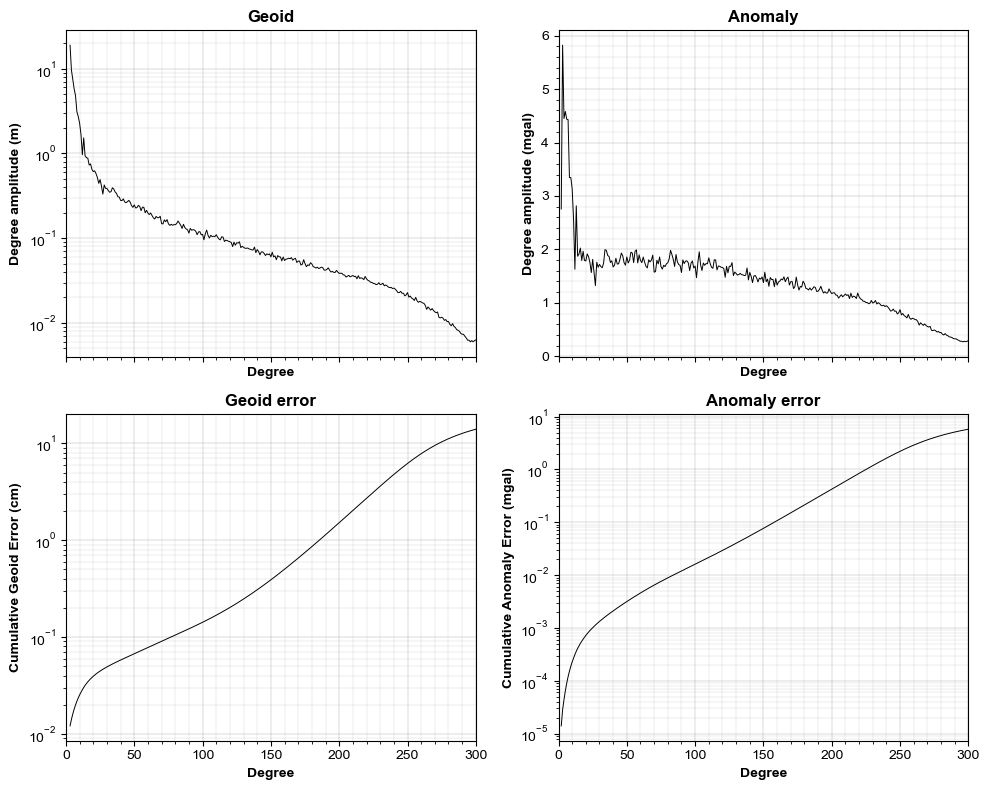

In [5]:
fig, axs = plt.subplots(2,2, figsize=(10,8), sharex=True)

axs = axs.ravel()

axs[0].plot(variances['degree'][3:], variances['geoid'][3:], linewidth=0.7, color='k')
axs[1].plot(variances['degree'][2:], variances['anomaly'][2:], linewidth=0.7, color='k')
axs[2].plot(error_variances['degree'][3:], error_variances['error_geoid'][3:], linewidth=0.7, color='k')
axs[3].plot(error_variances['degree'][2:], error_variances['error_anomaly'][2:], linewidth=0.7, color='k')

titles = ['Geoid', 'Anomaly', 'Geoid error', 'Anomaly error']
ylabels = ['Degree amplitude (m)', 'Degree amplitude (mgal)', 'Cumulative Geoid Error (cm)', 'Cumulative Anomaly Error (mgal)']

xlims  = [0, shc['nmax']]
ylims  = [[0, 20], [0, 6]]

for i, (ax, title) in enumerate(zip(axs, titles)):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Degree', fontweight='bold')
    ax.set_ylabel(ylabels[i], fontweight='bold')
    ax.set_xlim(xlims)
    
    if i != 1:
        ax.set_yscale('log')
    
    ax.grid(which='both', linewidth=0.5, color='gray')
    ax.minorticks_on()
    ax.grid(which='minor', linewidth=0.1, color='gray')
    ax.grid(linewidth=0.2)


fig.tight_layout()
plt.show()

# Gravity Field Functionals

In [6]:
grav_data = pd.read_csv('MeanTideGravity.csv')
grav_data.head()

,lon,lat,height,gravity
0,-0.166667,5.600000,66.45,978100.60
1,-0.183333,5.600000,96.32,978091.07
2,-0.333333,5.800000,50.29,978086.51
3,-0.083333,5.883333,73.15,978092.46
4,-0.033333,6.066667,83.82,978086.30


In [7]:
step = 0.0833
lon = np.arange(-4, 2+step, step)
lat = np.arange(4, 12+step, step)
# lon = np.arange(-180, 180+1, 1)
# lat = np.arange(-90, 90+1, 1)
lon, lat = np.meshgrid(lon, lat)

grav_data = pd.DataFrame(
    {
        'lon': lon.flatten(),
        'lat': lat.flatten(),
        'height': 0,
        'gravity': 0
    }
)
grav_data.shape

(7252, 4)

In [8]:
ggm = ggm_tools.GlobalGeopotentialModel(
    model_name='GO_CONS_GCF_2_TIM_R6e.gfc', 
    grav_data=grav_data, 
    ellipsoid='wgs84', 
    nmax=300, 
    zonal_harmonics=True, 
    model_dir='downloads',
    chunk_size=200
)

Setting r = R ...


In [12]:
Dg  = ggm.gravity_anomaly()
dg  = ggm.gravity_disturbance()
T   = ggm.disturbing_potential()
Tzz = ggm.second_radial_derivative()
Zeta= ggm.height_anomaly(T=T)
N   = ggm.geoid()
Z2N = ggm.separation()

Processing chunk 37 of 37...



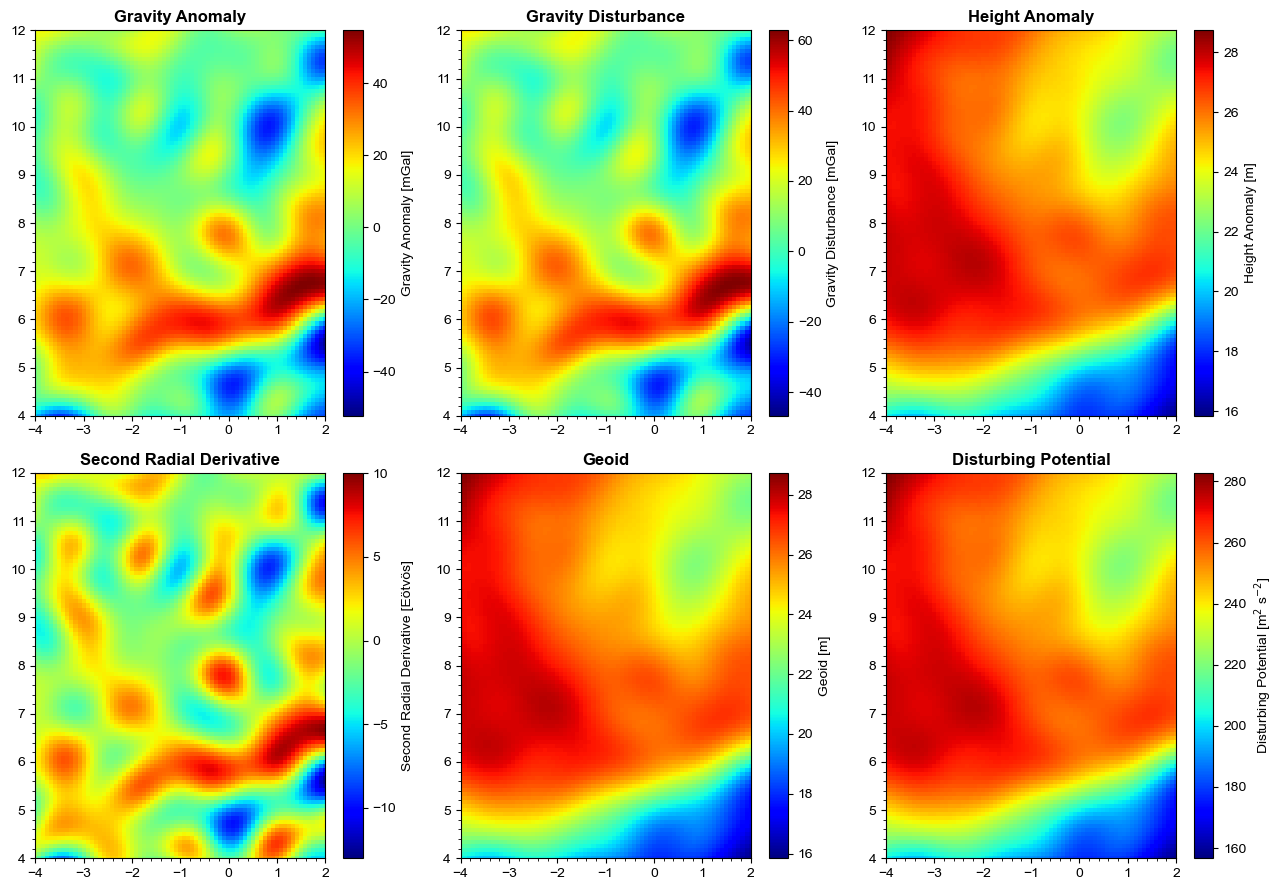

In [13]:
titles = [
    'Gravity Anomaly', 'Gravity Disturbance', 
    'Height Anomaly', 'Second Radial Derivative',
    'Geoid', 'Disturbing Potential'
]
fig, axs = plt.subplots(2, 3, figsize=[13,9])
axs = axs.ravel()

im = axs[0].pcolormesh(lon, lat, Dg.reshape(lon.shape), cmap='jet')
fig.colorbar(im, ax=axs[0], label='Gravity Anomaly [mGal]')

im = axs[1].pcolormesh(lon, lat, dg.reshape(lon.shape), cmap='jet')
fig.colorbar(im, ax=axs[1], label='Gravity Disturbance [mGal]')

im = axs[2].pcolormesh(lon, lat, Zeta.reshape(lon.shape), cmap='jet')
fig.colorbar(im, ax=axs[2], label='Height Anomaly [m]')

im = axs[3].pcolormesh(lon, lat, Tzz.reshape(lon.shape), cmap='jet')
fig.colorbar(im, ax=axs[3], label='Second Radial Derivative [Eötvös]')

im = axs[4].pcolormesh(lon, lat, N.reshape(lon.shape), cmap='jet')
fig.colorbar(im, ax=axs[4], label='Geoid [m]')

im = axs[5].pcolormesh(lon, lat, T.reshape(lon.shape), cmap='jet')
fig.colorbar(im, ax=axs[5], label='Disturbing Potential [m$^2$ s$^{-2}$]')

for ax, title in zip(axs, titles):
    ax.grid(which='both', linewidth=0.0, color='gray')
    ax.minorticks_on()
    ax.grid(which='minor', linewidth=0., color='gray')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim([-4, 2])
    ax.set_ylim([4, 12])

fig.tight_layout()
plt.show()

# titles = [
#     'Gravity Anomaly', 'Gravity Disturbance', 
#     'Height Anomaly', 'Second Radial Derivative',
#     'Geoid', 'Disturbing Potential'
# ]
# fig, axs = plt.subplots(2, 3, figsize=[15,7])
# axs = axs.ravel()

# im = axs[0].pcolormesh(lon, lat, Dg.reshape(lon.shape), cmap='jet', vmin=-100, vmax=100)
# fig.colorbar(im, ax=axs[0], label='Gravity Anomaly [mGal]')

# im = axs[1].pcolormesh(lon, lat, dg.reshape(lon.shape), cmap='jet', vmin=-100, vmax=100)
# fig.colorbar(im, ax=axs[1], label='Gravity Disturbance [mGal]')

# im = axs[2].pcolormesh(lon, lat, Zeta.reshape(lon.shape), cmap='jet', vmin=-100, vmax=100)
# fig.colorbar(im, ax=axs[2], label='Height Anomaly [m]')

# im = axs[3].pcolormesh(lon, lat, Tzz.reshape(lon.shape), cmap='jet', vmin=-10, vmax=10)
# fig.colorbar(im, ax=axs[3], label='Second Radial Derivative [Eötvös]')

# im = axs[4].pcolormesh(lon, lat, N.reshape(lon.shape), cmap='jet', vmin=-100, vmax=100)
# fig.colorbar(im, ax=axs[4], label='Geoid [m]')

# im = axs[5].pcolormesh(lon, lat, T.reshape(lon.shape), cmap='jet')
# fig.colorbar(im, ax=axs[5], label='Disturbing Potential [m$^2$ s$^{-2}$]')

# for ax, title in zip(axs, titles):
#     ax.grid(which='both', linewidth=0.0, color='gray')
#     ax.minorticks_on()
#     ax.grid(which='minor', linewidth=0., color='gray')
#     ax.set_title(title, fontweight='bold')
#     # ax.set_xlim([-4, 2])
#     # ax.set_ylim([4, 12])

# fig.tight_layout()
# plt.show()

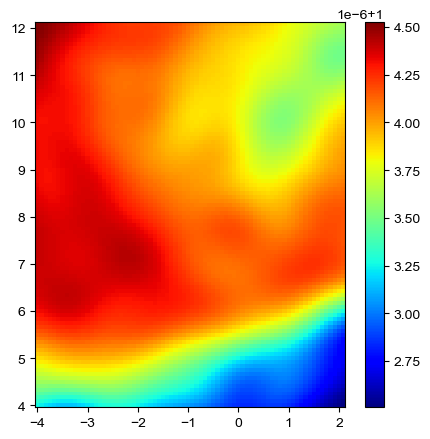

In [14]:
plt.figure(figsize=[5,5])
plt.pcolormesh(lon, lat, Z2N.reshape(lon.shape), cmap='jet')
plt.colorbar()
plt.show()

# N.reshape(lon.shape) - Zeta.reshape(lon.shape)

In [14]:
ggm2D = ggm_tools.GlobalGeopotentialModel2D(
    model_name='GO_CONS_GCF_2_TIM_R6e.gfc', 
    ellipsoid='grs80', 
    nmax=300, 
    zonal_harmonics=True, 
    model_dir='downloads',
    grid_spacing=1
)

No grid coordinates provided. Computing over the entire globe...



In [16]:
_, _, Dg_2D = ggm2D.gravity_anomaly_2D()
_, _, dg2D  = ggm2D.gravity_disturbance_2D()
_, _, Tzz2D = ggm2D.second_radial_derivative_2D()
_, _, N2D   = ggm2D.geoid_2D()
_, _, T2D   = ggm2D.disturbing_potential_2D()

Computing gravity anomalies: 100%|██████████| 181/181 [00:12<00:00, 14.29it/s]


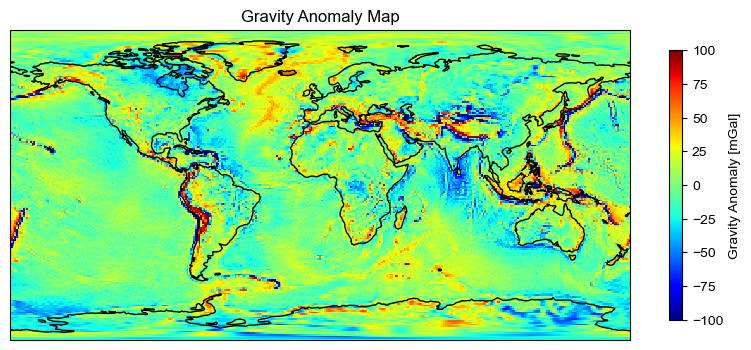

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()

# Plot the data
im = ax.pcolormesh(ggm2D.Lon, ggm2D.Lat, Dg_2D, cmap='jet', transform=ccrs.PlateCarree(), vmin=-100, vmax=100)
fig.colorbar(im, ax=ax, orientation='vertical', label='Gravity Anomaly [mGal]', shrink=.7)

ax.set_title('Gravity Anomaly Map')
plt.show()

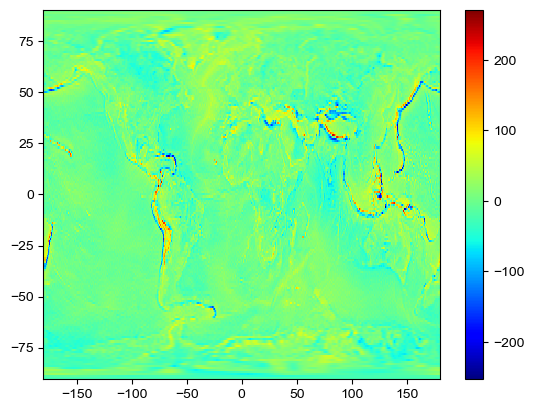

In [17]:
plt.pcolormesh(ggm2D.Lon, ggm2D.Lat, Dg_2D, cmap='jet')
plt.colorbar()

In [4]:
from pathlib import Path
def get_ggm_tide_system(icgem_file: str) -> str:
    '''
    Extract the permanent tide system from an ICGEM .gfc file.

    Parameters
    ----------
    icgem_file : The path to the ICGEM .gfc file.

    Returns
    -------
    tide_sys: The permanent tide system of the model (e.g., 'zero', 'free', 'mean').
    '''
    icgem_file = Path(icgem_file).resolve()
    
    if not icgem_file.exists():
        raise FileNotFoundError(f'{icgem_file} does not exist.')

    with open(icgem_file, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if 'tide_system' in line:
                return line.split()[1]
            # if 'end_of_head' in line:
            #     break
            # if 'tide_system' in line:
            #     parts = line.split()
            #     if len(parts) > 1:
            #         return parts[1]
    raise ValueError('Tide system not found in the file.')

In [5]:
downloads_dir = Path('/Users/kelly/Documents/Github/geoidlab/Notebooks/downloads')
ggm_list = list(downloads_dir.glob('*.gfc'))
ggm_list

[PosixPath('/Users/kelly/Documents/Github/geoidlab/Notebooks/downloads/GO_CONS_GCF_2_DIR_R6.gfc'),
 PosixPath('/Users/kelly/Documents/Github/geoidlab/Notebooks/downloads/EGM2008.gfc'),
 PosixPath('/Users/kelly/Documents/Github/geoidlab/Notebooks/downloads/GO_CONS_GCF_2_TIM_R6e.gfc'),
 PosixPath('/Users/kelly/Documents/Github/geoidlab/Notebooks/downloads/GO_CONS_GCF_2_SPW_R5.gfc')]

In [14]:
# model_path = model_path / '.gfc'
model_path = ggm_list[0]
# model_path + '.gfc'
# Append .gfc to model_path
model_path = model_path.with_suffix('.gfc')
model_path

PosixPath('/Users/kelly/Documents/Github/geoidlab/Notebooks/downloads/GO_CONS_GCF_2_DIR_R6.gfc')

In [7]:
# Get extension
ggm_list[0].suffix


'.gfc'

In [25]:
for ggm in ggm_list:
    print(f'Tide system for {ggm.stem:<22}:   {get_ggm_tide_system(ggm)}')


Tide system for GO_CONS_GCF_2_DIR_R6  :   tide_free
Tide system for EGM2008               :   tide_free
Tide system for GO_CONS_GCF_2_TIM_R6e :   zero_tide
Tide system for GO_CONS_GCF_2_SPW_R5  :   tide_free


In [1]:
from pathlib import Path

In [2]:
model = '/Users/kelly/Documents/Github/geoidlab/Notebooks/downloads/GO_CONS_GCF_2_DIR_R6.gfc'
model = Path(model)
model.stem

'GO_CONS_GCF_2_DIR_R6'